# Active Learning and Closed-Loop ADC Target Discovery

**v0.1 educational notebook**

## Goal
Use a surrogate model to choose the next experimental batch by combining predicted value, uncertainty, and diversity.

**Data mode:** Closed-loop educational simulation. Random-forest tree variation is used only as an uncertainty proxy, not as complete biological uncertainty.

## Canonical guide

### Learning objectives
- Train a simple surrogate on tested candidates.
- Compare exploitation, uncertainty, UCB, Expected Improvement, and diversity-aware selection.
- Record the next-batch decision as part of a closed-loop digital thread.

### Data mode
Educational closed-loop simulation using only the small simulated experimental set from Notebook 08.

### Inputs
`outputs/adc_target_feature_matrix_v02.csv`, `outputs/adc_experimental_results_001.csv`

### Canonical outputs
`outputs/adc_experimental_batch_002.csv`, `outputs/adc_active_learning_round_001.csv`

### Scientific limitation
The training set is intentionally tiny. Random-forest tree dispersion is not a full Bayesian uncertainty estimate, and EI is used with a normal approximation for teaching.

### Next step
Notebook 10 changes the unit of analysis from target to ADC construct.


In [1]:
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print('ROOT:', ROOT.resolve())

ROOT: /mnt/data/audit_adc/adc-scientific-ai


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import norm
fm=pd.read_csv(OUTPUTS/'adc_target_feature_matrix_v02.csv',index_col=0)
cols=['tumor_score','selectivity_score','prevalence_score','surface_score_norm','heterogeneity_risk','normal_rna_risk','normal_protein_risk_norm','critical_organ_risk']
tested=fm[fm.functional_adc_score.notna()].dropna(subset=cols).copy(); pool=fm[fm.functional_adc_score.isna()].dropna(subset=cols).copy()
print('tested',len(tested),'pool',len(pool))

tested 6 pool 18


In [3]:
model=RandomForestRegressor(n_estimators=200,min_samples_leaf=2,random_state=42,n_jobs=1)
model.fit(tested[cols],tested.functional_adc_score)
tree=np.vstack([t.predict(pool[cols]) for t in model.estimators_]); pool['predicted_mean']=tree.mean(0); pool['predicted_uncertainty']=tree.std(0)
beta=.5; pool['ucb_score']=pool.predicted_mean+beta*pool.predicted_uncertainty
def expected_improvement(mean,std,best,xi=.01):
    std=np.maximum(np.asarray(std),1e-9); imp=np.asarray(mean)-best-xi; z=imp/std; return np.maximum(imp*norm.cdf(z)+std*norm.pdf(z),0)
pool['expected_improvement']=expected_improvement(pool.predicted_mean,pool.predicted_uncertainty,tested.functional_adc_score.max())
pool.sort_values('expected_improvement',ascending=False).head()

/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: 

,tumor_mean,tumor_median,tumor_sd,tumor_iqr,normal_mean,normal_median,delta_expression,tumor_prevalence,normal_prevalence,hpa_normal_max,n_normal_tissues_positive,normal_tissue_fraction_positive,n_normal_celltypes_positive,critical_organ_max,n_critical_tissues_positive,normal_protein_risk,hpa_missing,surface_score,surface_confidence,surface_missing,surface_eligible,tumor_score,selectivity_score,prevalence_score,surface_score_norm,heterogeneity_risk,normal_rna_risk,normal_protein_risk_norm,critical_organ_risk,scorable,benefit_score,risk_score,adc_target_score_raw,passes_hard_filters,binding_score,internalization_score,lysosome_score,adc_killing_score,functional_adc_score,functional_positive,has_experimental_data,predicted_mean,predicted_uncertainty,ucb_score,expected_improvement
gene_symbol,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TACSTD2,7.971553,7.896318,1.227710,1.586680,0.496157,0.394122,7.502196,1.000,0.000,3,3,0.375,1,3,3,0.875000,False,1.0,high,False,True,0.770703,0.905579,1.000,1.0,0.120905,0.000000,0.875000,1.000000,True,0.914349,0.624386,0.289964,False,NaN,NaN,NaN,NaN,NaN,NaN,False,0.543607,0.094509,0.590861,0.003701
ERBB2,9.031177,8.929292,0.965318,1.329676,0.567109,0.558175,8.371116,1.000,0.000,2,4,0.500,1,2,3,0.633333,False,1.0,high,False,True,0.916993,1.000000,1.000,1.0,0.053299,0.035680,0.633333,0.666667,True,0.979248,0.436797,0.542451,True,NaN,NaN,NaN,NaN,NaN,NaN,False,0.536541,0.091851,0.582466,0.002776
GENE_P,6.330362,6.365317,1.205197,1.209735,3.418997,3.321619,3.043698,0.975,0.175,3,5,0.625,1,3,3,0.925000,False,0.9,high,False,True,0.553881,0.408098,0.975,0.9,0.021747,0.816226,0.925000,1.000000,True,0.684650,0.790257,-0.105608,False,NaN,NaN,NaN,NaN,NaN,NaN,False,0.496451,0.092666,0.542784,0.001008
GENE_L,5.472077,5.655792,1.261900,1.395122,1.970394,1.867205,3.788587,0.875,0.000,3,4,0.500,1,3,4,0.900000,False,0.9,high,False,True,0.453397,0.491213,0.875,0.9,0.070515,0.405421,0.900000,1.000000,True,0.659463,0.706661,-0.047198,False,NaN,NaN,NaN,NaN,NaN,NaN,False,0.496451,0.092666,0.542784,0.001008
GENE_N,4.181704,3.584801,2.648693,4.970999,2.871775,2.954852,0.629949,0.500,0.050,3,6,0.750,1,3,4,0.950000,False,0.8,medium,False,True,0.160102,0.138771,0.500,0.8,1.000000,0.712632,0.950000,1.000000,True,0.366657,0.925026,-0.558370,False,NaN,NaN,NaN,NaN,NaN,NaN,False,0.492447,0.092550,0.538722,0.000894


In [4]:
def diverse_greedy(table,features,acq='expected_improvement',batch_size=8,diversity_weight=.30):
    if len(table)<=batch_size: return table.copy()
    X=StandardScaler().fit_transform(table[features]); D=pairwise_distances(X); a=table[acq].to_numpy(float); a=(a-a.min())/(a.max()-a.min()+1e-12)
    selected=[int(np.argmax(a))]
    while len(selected)<batch_size:
        best_i,best_u=None,-np.inf
        for i in range(len(table)):
            if i in selected: continue
            min_d=D[i,selected].min(); u=(1-diversity_weight)*a[i]+diversity_weight*min_d
            if u>best_u: best_i,best_u=i,u
        selected.append(best_i)
    return table.iloc[selected].copy()
next_batch=diverse_greedy(pool,cols,batch_size=min(8,len(pool)))
next_batch['selection_strategy']='DIVERSITY_AWARE_EI'; next_batch.to_csv(OUTPUTS/'adc_experimental_batch_002.csv')
log=pool[['predicted_mean','predicted_uncertainty','ucb_score','expected_improvement']].copy(); log['round']=1; log['model_version']='RF_SURROGATE_V01'; log['selected']=log.index.isin(next_batch.index); log.to_csv(OUTPUTS/'adc_active_learning_round_001.csv')
next_batch[['predicted_mean','predicted_uncertainty','expected_improvement']]

,predicted_mean,predicted_uncertainty,expected_improvement
gene_symbol,,,
TACSTD2,0.543607,0.094509,3.701491e-03
GENE_M,0.445536,0.055285,2.349926e-07
GENE_S,0.457529,0.063212,5.269733e-06
GENE_H,0.452728,0.059302,1.439703e-06
GENE_F,0.491844,0.092611,8.818334e-04
GENE_N,0.492447,0.092550,8.935324e-04
GENE_C,0.444934,0.054873,1.927290e-07
ERBB2,0.536541,0.091851,2.775731e-03


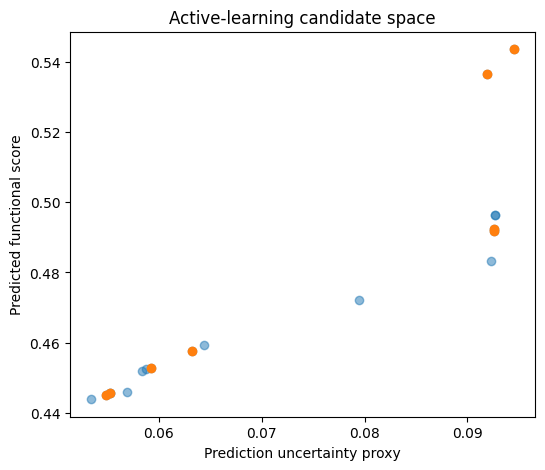

In [5]:
plt.figure(figsize=(6,5)); plt.scatter(pool.predicted_uncertainty,pool.predicted_mean,alpha=.5); plt.scatter(next_batch.predicted_uncertainty,next_batch.predicted_mean); plt.xlabel('Prediction uncertainty proxy'); plt.ylabel('Predicted functional score'); plt.title('Active-learning candidate space'); plt.show()

## Closed-loop concept
Model → prediction + uncertainty → acquisition → experiment → QC → validated result → model update → next acquisition. In a real SDL, provenance, batch metadata, assay QC, and model versioning must be recorded before experimental results enter the next training round.